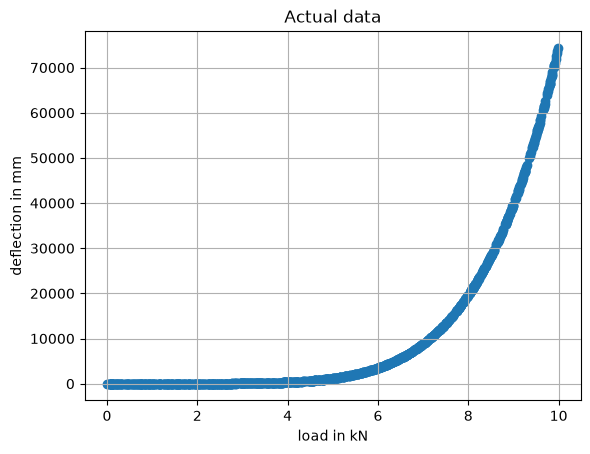

In [ ]:
# Import numerical, plotting, neural-network, and preprocessing tools.
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RNG = 10
np.random.seed(RNG)

# Reproduce the synthetic load-deflection observations from Problem 2.
rng = np.random.default_rng(4452)
load_kN = rng.uniform(0, 10, 1000)
noise = rng.normal(0, 2.5 + 0.15 * load_kN, 1000)
deflection_mm = 6.0 + 1.45 * load_kN - 0.48 * load_kN**2 + 0.075 * load_kN**3 + noise

plt.scatter(load_kN, deflection_mm)
plt.xlabel('load in kN')
plt.ylabel('deflection in mm')
plt.title('Actual data')
plt.grid()

In [2]:

# Hold out 20% of the observations to inspect predictions on unseen data.
X_train, X_val, y_train, y_val = train_test_split(
    load_kN.reshape(-1, 1), deflection_mm.reshape(-1, 1), test_size=0.2, random_state=RNG
)

# Fit separate scalers on training data only, then make float32 PyTorch tensors.
x_scaler = StandardScaler().fit(X_train)
y_scaler = StandardScaler().fit(y_train)
x_train = torch.tensor(x_scaler.transform(X_train), dtype=torch.float32)
y_train_tensor = torch.tensor(y_scaler.transform(y_train), dtype=torch.float32)

In [3]:
# Fix the initial weights so reruns are reproducible.
torch.manual_seed(RNG)

# Pass one load value through two ReLU hidden layers to predict one deflection.
model = nn.Sequential(
    nn.Linear(1, 16), nn.ReLU(),
    nn.Linear(16, 8), nn.ReLU(),
    nn.Linear(8, 1),
)
print(model)  # Show the exact PyTorch layers.

Sequential(
  (0): Linear(in_features=1, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=1, bias=True)
)


0.0005376175977289677


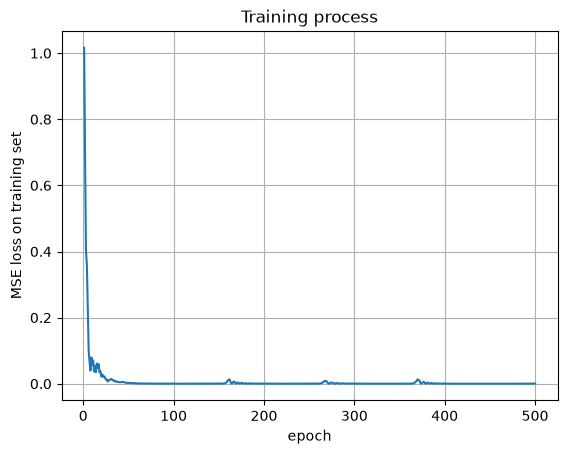

In [4]:
# Adam adjusts the network's weights using the gradients of mean squared loss.
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
model.train()
Losses = []

# Save the starting weights, then one snapshot every 10 training updates.
linear_layers = [layer for layer in model if isinstance(layer, nn.Linear)]
def capture_weights():
    return [layer.weight.detach().cpu().numpy().copy() for layer in linear_layers]

snapshot_epochs = [0]
weight_snapshots = [capture_weights()]
with torch.no_grad():
    snapshot_losses = [nn.functional.mse_loss(model(x_train), y_train_tensor).item()]

# Each epoch makes one full-batch update from the training observations.
for epoch in range(500):
    optimizer.zero_grad()  # Clear gradients from the previous update.
    loss = nn.functional.mse_loss(model(x_train), y_train_tensor)
    loss.backward()  # Compute gradients by backpropagation.
    optimizer.step()  # Update the weights.
    Losses.append(loss.item())

    if (epoch + 1) % 10 == 0:
        snapshot_epochs.append(epoch + 1)
        weight_snapshots.append(capture_weights())
        with torch.no_grad():
            snapshot_losses.append(nn.functional.mse_loss(model(x_train), y_train_tensor).item())

plt.plot(np.arange(1, 501), Losses)
plt.xlabel('epoch')
plt.ylabel('MSE loss on training set')
plt.grid()
plt.title('Training process')
print(Losses[-1])


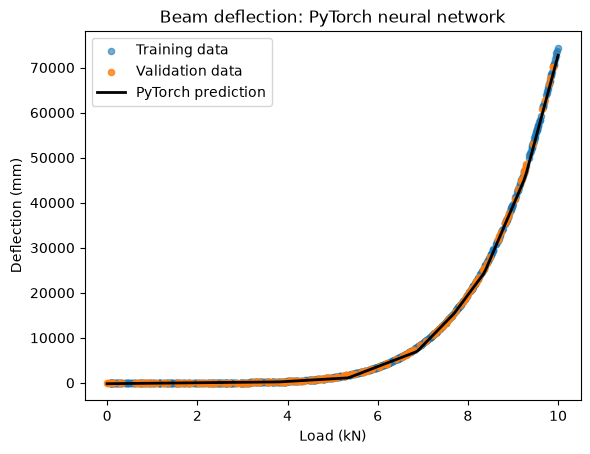

In [5]:
# Evaluate the trained model on a smooth load grid.
model.eval()
x_plot = np.linspace(0, 10, 200).reshape(-1, 1)
x_plot_scaled = torch.tensor(x_scaler.transform(x_plot), dtype=torch.float32)
with torch.no_grad():
    y_scaled = model(x_plot_scaled)
# Convert predicted values back to millimeters for the plot.
y_plot = y_scaler.inverse_transform(y_scaled)

# Compare the fitted curve with training points and held-out validation points.
plt.scatter(X_train, y_train, s=20, alpha=0.6, label="Training data")
plt.scatter(X_val, y_val, s=20, alpha=0.8, label="Validation data")
plt.plot(x_plot, y_plot, color="black", linewidth=2, label="PyTorch prediction")
plt.xlabel("Load (kN)")
plt.ylabel("Deflection (mm)")
plt.title("Beam deflection: PyTorch neural network")
plt.legend()
plt.show()

In [6]:

x_test = torch.tensor(x_scaler.transform(X_val), dtype=torch.float32)
y_test_tensor = torch.tensor(y_scaler.transform(y_val), dtype=torch.float32)
nn.functional.mse_loss(model(x_test), y_test_tensor).item()

0.0006847238400951028

In [ ]:
# Animate the three learned weight matrices; biases are omitted for clarity.
# Every heatmap uses the same fixed color scale, so colors are comparable over time.
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

weight_limit = max(
    np.max(np.abs(weights))
    for snapshot in weight_snapshots
    for weights in snapshot
)
fig, axes = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True)
heat_axes = [axes[0, 0], axes[0, 1], axes[1, 0]]
labels = [
    ('Input → hidden layer 1 (16 × 1)', 'Input feature', 'Hidden neuron'),
    ('Hidden layer 1 → 2 (8 × 16)', 'Layer 1 neuron', 'Layer 2 neuron'),
    ('Hidden layer 2 → output (1 × 8)', 'Layer 2 neuron', 'Output neuron'),
]
images = []
for ax, weights, (title, xlabel, ylabel) in zip(heat_axes, weight_snapshots[0], labels):
    image = ax.imshow(
        weights, cmap='RdBu_r', vmin=-weight_limit, vmax=weight_limit,
        aspect='auto', interpolation='nearest'
    )
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    if len(images) == 0:
        ax.set_xticks([0], labels=['Load'])
        ax.set_yticks([0, 3, 7, 11, 15], labels=['1', '4', '8', '12', '16'])
    elif len(images) == 1:
        ax.set_xticks([0, 3, 7, 11, 15], labels=['1', '4', '8', '12', '16'])
        ax.set_yticks([0, 3, 7], labels=['1', '4', '8'])
    else:
        ax.set_xticks(range(8), labels=[str(i) for i in range(1, 9)])
        ax.set_yticks([0], labels=['Output'])
    images.append(image)
fig.colorbar(images[0], ax=heat_axes, label='Weight value', shrink=0.72)

loss_ax = axes[1, 1]
loss_ax.set(xlim=(0, 500), ylim=(0, max(snapshot_losses) * 1.05),
            xlabel='Epoch', ylabel='Training MSE', title='Loss so far')
loss_ax.grid(alpha=0.3)
loss_trace, = loss_ax.plot([], [], color='black', linewidth=2)
loss_point, = loss_ax.plot([], [], 'o', color='tab:orange')

def update(frame):
    for image, weights in zip(images, weight_snapshots[frame]):
        image.set_data(weights)
    epochs_so_far = snapshot_epochs[:frame + 1]
    losses_so_far = snapshot_losses[:frame + 1]
    loss_trace.set_data(epochs_so_far, losses_so_far)
    loss_point.set_data([snapshot_epochs[frame]], [snapshot_losses[frame]])
    fig.suptitle(
        f'Epoch {snapshot_epochs[frame]} / 500   |   Training MSE {snapshot_losses[frame]:.4f}'
    )
    return [*images, loss_trace, loss_point]

animation = FuncAnimation(fig, update, frames=len(snapshot_epochs),
                          interval=167, repeat=True, blit=False)
animation_path = 'nn_weights_training.gif'
animation.save(animation_path, writer=PillowWriter(fps=6), dpi=90)
plt.close(fig)
display(Image(filename=animation_path))


### Weight changes during training
Blue shows negative weights, red shows positive weights, and pale colors are near zero. The color scale stays fixed across all frames. Each frame represents 10 epochs; the loss plot shows the matching training loss.

![Animated weight heatmaps during neural-network training](nn_weights_training.gif)
